In [1]:
import os, pickle

from physics.simulation import msq, mcfm
from physics.hzz import zpair, zz4l
from physics.hstar import c6

from models import rolypoly

import numpy as np
import hist
import matplotlib.pyplot as plt
import pandas as pd

import torch

In [2]:
META_DIR = '../jobs/rolypoly/refactor-four-SIG'
COMPONENT = msq.Component.SIG
COMPONENT_FILE = msq.Component.SIG

SAMPLE_SIZE = 200000

CHECKPOINTS = [(26,0.08),
               (181,'0.00'),
               (180,0.12),
               (126,'0.00')]

FEATURES = ['mandelstam_s', 'mandelstam_t', 'mandelstam_u']

SEED = 42

DIRS = [os.path.join(META_DIR, f'coeff_{i}') for i in range(1,5)] if COMPONENT != msq.Component.INT else [os.path.join(META_DIR, f'coeff_{i}') for i in range(1,3)]
CHECKPOINT_DIRS = [os.path.join(DIRS[i], 'checkpoints', f'checkpoint-rolypoly-epoch={CHECKPOINTS[i][0]}-val_loss={CHECKPOINTS[i][1]}.ckpt') for i in range(len(DIRS))]
SAMPLE_FILE = os.path.join('../..', {msq.Component.SBI:'ggZZ2e2m_sbi.csv',msq.Component.SIG:'ggZZ2e2m_sig.csv',msq.Component.INT:'ggZZ2e2m_int.csv',msq.Component.BKG:'ggZZ2e2m_bkg.csv'}[COMPONENT_FILE])
CMP_NAME = {msq.Component.SBI:'SBI',msq.Component.SIG:'SIG',msq.Component.BKG:'BKG',msq.Component.INT:'INT'}[COMPONENT]

In [ ]:
events = mcfm.from_csv(cross_section=1.0, file_path=SAMPLE_FILE, n_rows=1.2*SAMPLE_SIZE).reweight(COMPONENT_FILE, COMPONENT)

zcand = zpair.ZPairCandidate(algorithm='leastsquare')
zmasses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))

angles = zz4l.AngularVariables()
fourlep = zz4l.FourLeptonSystem()
mandelstam = zz4l.MandelstamVariables()

events_processed = events.calculate(zcand).filter(zmasses).calculate(mandelstam).calculate(fourlep).calculate(angles)[:SAMPLE_SIZE]

0.12066544832123541


In [4]:
c6_mod = c6.Modifier(baseline=COMPONENT, events=events_processed, c6_values=[-5,-1,0,1,5]) if COMPONENT!=msq.Component.INT else c6.Modifier(baseline=COMPONENT, events=events, c6_values=[-5,0,5])

datasets = []

unweighted_indices = events_processed.weights.sample(n=SAMPLE_SIZE, replace=True, weights=events_processed.weights, random_state=SEED).index

for i in range(len(DIRS)):
    coefficient = c6_mod.coefficients[:,i+1]
    X = events_processed.kinematics[FEATURES].to_numpy()[unweighted_indices]

    with open(os.path.join(DIRS[i], 'scaler_X.pkl'), 'rb') as f:
        scaler_X = pickle.load(f)

    X = torch.tensor(scaler_X.transform(X), dtype=torch.float32).cpu()
    y = coefficient[unweighted_indices]

    dataset = torch.utils.data.TensorDataset(X, torch.tensor(y, dtype=torch.float32))
    datasets.append(dataset)

events_unweighted = mcfm.Process(events_processed.kinematics.iloc[unweighted_indices].reset_index(drop=True),
                                 events_processed.components.iloc[unweighted_indices].reset_index(drop=True),
                                 pd.Series(np.ones(len(unweighted_indices))).reset_index(drop=True))

In [5]:
models = [rolypoly.ROLYPOLY.load_from_checkpoint(checkpoint_path=CHECKPOINT_DIRS[i]) for i in range(len(DIRS))]

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [6]:
predictions = np.array([pickle.load(open(os.path.join(DIRS[i], 'scaler_y.pkl'), 'rb')).inverse_transform(models[i](datasets[i].tensors[0]).detach().numpy()) for i in range(len(DIRS))]).T.squeeze(0)

In [7]:
predicted_coefficients = np.concatenate([np.ones((predictions.shape[0],1)), predictions], axis=1)
true_coefficients = np.concatenate([np.ones((predictions.shape[0],1)), np.array([datasets[i].tensors[1].detach().numpy() for i in range(len(datasets))]).T], axis=1)

In [8]:
c6_value = -10

reweight_pred = np.apply_along_axis(lambda x: np.polyval(x, c6_value), 1, predicted_coefficients[:, ::-1])
reweight_truth = np.apply_along_axis(lambda x: np.polyval(x, c6_value), 1, true_coefficients[:, ::-1])

/tmp/ipykernel_12282/1086700010.py:54: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].centers, hist_sm.values()/hist_sm.values(), yerr=np.sqrt(hist_sm.variances())/hist_sm.values(), color='black', linestyle='--', drawstyle='steps-mid', label=f'{CMP_NAME}', alpha=0.8)
/tmp/ipykernel_12282/1086700010.py:55: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].centers, hist_c6_pred.values()/hist_sm.values(), yerr=np.sqrt((np.sqrt(hist_c6_pred.variances())/hist_sm.values())**2 + (- np.sqrt(hist_sm.variances())*hist_c6_pred.values()/hist_sm.values()**2)**2), color='r', drawstyle='steps-mid', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (prediction)')
/tmp/ipykernel_12282/1086700010.py:56: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].centers, hist_c6_truth.values()/hist_sm.values(), yerr=np.sqrt((np.sqrt(hist_c6_truth.variances())/hist_sm.values())**2 + (- np.sqrt(hist_sm.variances(

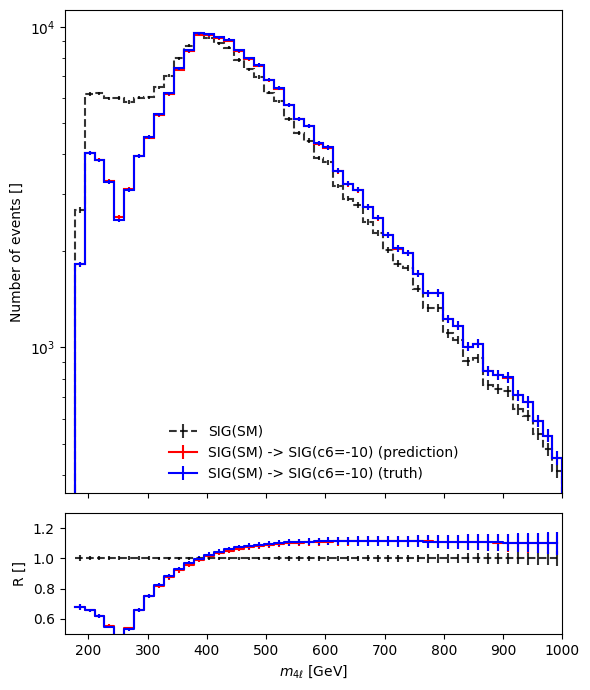

In [13]:
index = 7

PLOT_FEATURES = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

X = events_unweighted.kinematics[PLOT_FEATURES].to_numpy()

kin_var = X[:,index]
label = ['$\mathrm{cos}(\\theta^*)$ []',
         '$\mathrm{cos}(\\theta_1)$ []',
         '$\mathrm{cos}(\\theta_2)$ []',
         '$\phi$ []',
         '$\phi_1$ []',
         '$m_{Z1}$ [GeV]',
         '$m_{Z2}$ [GeV]',
         '$m_{4\ell}$ [GeV]',
         '$y_{4\ell}$ []'][index]
bounds = [[-1,1],
          [-1,1],
          [-1,1],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [70,115],
          [70,115],
          [160,1000],
          [-2.4,2.4]][index]


BINS=50

hist_sm = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_sm.fill(kin_var, weight=events_unweighted.weights.to_numpy())

hist_c6_pred = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_c6_pred.fill(kin_var, weight=reweight_pred)

hist_c6_truth = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_c6_truth.fill(kin_var, weight=reweight_truth)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

hist_sm.plot(ax=ax1, color='k', linestyle='--', label=f'{CMP_NAME}(SM)', alpha=0.8, yerr=np.sqrt(hist_sm.variances()))
hist_c6_pred.plot(ax=ax1, color='r', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (prediction)', yerr=np.sqrt(hist_c6_pred.variances()))
hist_c6_truth.plot(ax=ax1, color='b', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (truth)', yerr=np.sqrt(hist_c6_truth.variances()))

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.set_xlabel('')

ax1.legend(frameon=False)

ax2.errorbar(hist_sm.axes[0].centers, hist_sm.values()/hist_sm.values(), yerr=np.sqrt(hist_sm.variances())/hist_sm.values(), color='black', linestyle='--', drawstyle='steps-mid', label=f'{CMP_NAME}', alpha=0.8)
ax2.errorbar(hist_sm.axes[0].centers, hist_c6_pred.values()/hist_sm.values(), yerr=np.sqrt((np.sqrt(hist_c6_pred.variances())/hist_sm.values())**2 + (- np.sqrt(hist_sm.variances())*hist_c6_pred.values()/hist_sm.values()**2)**2), color='r', drawstyle='steps-mid', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (prediction)')
ax2.errorbar(hist_sm.axes[0].centers, hist_c6_truth.values()/hist_sm.values(), yerr=np.sqrt((np.sqrt(hist_c6_truth.variances())/hist_sm.values())**2 + (- np.sqrt(hist_sm.variances())*hist_c6_truth.values()/hist_sm.values()**2)**2), color='b', drawstyle='steps-mid', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (truth)')
         
ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
ax2.set_ybound(0.5,1.3)
ax2.set_xlim(*bounds)
fig.tight_layout()

plt.show()